In [1]:
import os
os.environ['HF_HOME'] = '/kaggle/temp/hf'
os.makedirs('/kaggle/temp/hf', exist_ok=True)

import glob, re, json, time, gc, shutil
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'
BASE = os.path.dirname(glob.glob('/kaggle/input/**/train.csv', recursive=True)[0])
asr_dirs = glob.glob('/kaggle/input/**/asr_raw', recursive=True)
assert len(asr_dirs) == 1, asr_dirs
ASR_DIR = asr_dirs[0]
WORK = '/kaggle/working'

train = pd.read_csv(f'{BASE}/train.csv')
test = pd.read_csv(f'{BASE}/test.csv')
uids = ['train/' + f for f in train.filename] + ['test/' + f for f in test.filename]
assert len(set(uids)) == len(uids) == 985

texts, dur = {}, {}
for u in uids:
    with open(f'{ASR_DIR}/{u.replace("/", "__")}.json') as f:
        r = json.load(f)
    texts[u] = re.sub(r'\s+', ' ', ' '.join(s['text'].strip() for s in r['segments'])).strip()
    dur[u] = r['duration']
print('transcripts loaded:', len(texts), '| empty:', sum(1 for t in texts.values() if not t))
print('free disk GB  temp:', round(shutil.disk_usage('/kaggle/temp').free / 1e9, 1),
      '| working:', round(shutil.disk_usage(WORK).free / 1e9, 1), '(model needs about 16 GB in temp)')
assert torch.cuda.is_available(), 'GPU is off'
print('gpus:', torch.cuda.device_count())

tok = AutoTokenizer.from_pretrained(MODEL_ID)
try:
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float16, device_map='auto')
except TypeError:
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map='auto')
model.eval()
print('loaded | layers:', model.config.num_hidden_layers, '| hidden:', model.config.hidden_size)
for g in range(torch.cuda.device_count()):
    print('gpu', g, 'memory GB:', round(torch.cuda.memory_allocated(g) / 1e9, 1))

transcripts loaded: 985 | empty: 0
free disk GB  temp: 1148.8 | working: 20.9 (model needs about 16 GB in temp)


gpus: 2


loaded | layers: 28 | hidden: 3584
gpu 0 memory GB: 6.7
gpu 1 memory GB: 8.5


In [2]:
# L2: prompt, judge function aur smoke test
from scipy.stats import spearmanr

RUBRIC = """1: The speech struggles with proper sentence structure and syntax, with limited control over simple grammatical structures and memorized sentence patterns.
2: Limited understanding of sentence structure and syntax. Simple structures are used, but basic sentence-structure and grammatical mistakes are consistent. Sentences may be left incomplete.
3: Decent grasp of sentence structure but errors in grammatical structure, or decent grasp of grammatical structure but errors in sentence syntax and structure.
4: Strong understanding of sentence structure and syntax, with consistently good control of grammar. Occasional errors are generally minor, do not cause misunderstanding, and most can be self-corrected.
5: High grammatical accuracy and adept control of complex grammar. Grammar is used accurately and effectively, with seldom any noticeable mistakes. Complex structures are handled well and the speaker corrects themselves when necessary."""

SYSTEM = 'You are an expert examiner of spoken English grammar.'

def build_prompt(text):
    user = (
        'Below is an automatic speech-recognition transcript of a 45 to 60 second spoken response. '
        "Rate ONLY the speaker's grammar (sentence structure, syntax, grammatical accuracy and control of complex structures). "
        'Do not rate vocabulary, pronunciation, fluency or the quality of the ideas. '
        'The transcript comes from speech recognition, so ignore capitalization and punctuation; '
        'repetitions and false starts are real features of the speech and may reflect grammar control.\n\n'
        'Grammar score rubric:\n' + RUBRIC + '\n\n'
        'Transcript:\n"""\n' + text + '\n"""\n\n'
        'Answer with a single digit from 1 to 5 and nothing else.')
    msgs = [{'role': 'system', 'content': SYSTEM}, {'role': 'user', 'content': user}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

digit_ids = []
for d in '12345':
    ids = tok.encode(d, add_special_tokens=False)
    assert len(ids) == 1, (d, ids)
    digit_ids.append(ids[0])

@torch.inference_mode()
def judge(uid):
    enc = tok(build_prompt(texts[uid]), return_tensors='pt').to(model.device)
    out = model(**enc, output_hidden_states=True, use_cache=False)
    logits = out.logits[0, -1].float()
    lp = torch.log_softmax(logits, -1)
    five = logits[digit_ids].cpu().numpy()
    p = np.exp(five - five.max())
    p /= p.sum()
    hs = np.stack([h[0, -1].float().cpu().numpy() for h in out.hidden_states], 0)   # (layers + 1, hidden)
    return dict(e=float((p * np.arange(1, 6)).sum()), p=p.tolist(), logit=five.tolist(),
                ent=float(-(p * np.log(p + 1e-12)).sum()),
                mass=float(lp[digit_ids].exp().sum().item()),
                ntok=int(enc['input_ids'].shape[1]), hs=hs)

lab = train.set_index('filename').label
samp = [u for u in uids[:len(train)] if lab[u.split('/')[1]] > 0][:60]
t0 = time.time()
res = [judge(u) for u in samp]
sec = (time.time() - t0) / len(samp)
e = np.array([r['e'] for r in res])
yy = np.array([lab[u.split('/')[1]] for u in samp])

print('seconds per file:', round(sec, 2), '| estimated total minutes:', round(sec * 985 / 60, 1))
print('digit probability mass: min', round(min(r['mass'] for r in res), 3), '(should be close to 1)')
print('prompt tokens: min', min(r['ntok'] for r in res), 'max', max(r['ntok'] for r in res))
print('NaN present:', bool(not np.isfinite(e).all() or not all(np.isfinite(r['hs']).all() for r in res)))
print('expected score: min', round(e.min(), 2), 'max', round(e.max(), 2), 'mean', round(e.mean(), 2))
print('Spearman(expected score, label) on', len(samp), 'train files:', round(spearmanr(e, yy)[0], 3), '(noisy, n=60)')
print('hidden shape:', res[0]['hs'].shape, '| largest abs hidden value:', round(float(max(np.abs(r['hs']).max() for r in res)), 1))
for g in range(torch.cuda.device_count()):
    print('gpu', g, 'peak memory GB:', round(torch.cuda.max_memory_allocated(g) / 1e9, 1))

seconds per file: 0.37 | estimated total minutes: 6.1
digit probability mass: min 1.0 (should be close to 1)
prompt tokens: min 358 max 476
NaN present: False
expected score: min 2.67 max 4.16 mean 3.42
Spearman(expected score, label) on 60 train files: 0.466 (noisy, n=60)
hidden shape: (29, 3584) | largest abs hidden value: 284.2
gpu 0 peak memory GB: 6.9
gpu 1 peak memory GB: 8.8


In [3]:
N = len(uids)
L1, D = model.config.num_hidden_layers + 1, model.config.hidden_size
P_HS, P_SC = f'{WORK}/_part_hs.npy', f'{WORK}/_part_scores.json'

if os.path.exists(P_SC):
    hs_all, recs = np.load(P_HS), json.load(open(P_SC))
    start = len(recs)
    print('resuming from', start)
else:
    hs_all, recs, start = np.zeros((N, L1, D), dtype=np.float16), [], 0

n_clipped = 0
t0 = time.time()
for i in range(start, N):
    r = judge(uids[i])
    h = r.pop('hs')
    n_clipped += int((np.abs(h) > 6e4).sum())
    hs_all[i] = np.clip(h, -6e4, 6e4).astype(np.float16)
    row = dict(uid=uids[i], e=r['e'], ent=r['ent'], mass=r['mass'], ntok=r['ntok'])
    for k in range(5):
        row[f'p{k + 1}'] = r['p'][k]
        row[f'l{k + 1}'] = r['logit'][k]
    recs.append(row)
    if (i + 1) % 100 == 0 or i + 1 == N:
        np.save(P_HS, hs_all)
        json.dump(recs, open(P_SC, 'w'))
        el = time.time() - t0
        print(f'{i + 1}/{N} | {el / 60:.1f} min | est remaining {(N - i - 1) * el / (i + 1 - start) / 60:.1f} min')

print('hidden values clipped at +-60000 (fp16 safety):', n_clipped)
print('NaN or inf in hidden states:', not np.isfinite(hs_all).all())
S = pd.DataFrame(recs)
print('rows:', len(S), '| NaN in scores:', int(S.drop(columns='uid').isna().sum().sum()))
S.to_csv(f'{WORK}/llm_scores.csv', index=False)
np.save(f'{WORK}/llm_hidden_last.npy', hs_all)
pd.Series(uids).to_csv(f'{WORK}/llm_uids.csv', index=False, header=['uid'])
for p in (P_HS, P_SC):
    os.remove(p)
print('saved', hs_all.shape, '|', sorted(os.listdir(WORK)))

100/985 | 0.6 min | est remaining 5.5 min
200/985 | 1.3 min | est remaining 5.0 min
300/985 | 2.0 min | est remaining 4.5 min
400/985 | 2.7 min | est remaining 3.9 min
500/985 | 3.3 min | est remaining 3.2 min
600/985 | 4.0 min | est remaining 2.6 min
700/985 | 4.7 min | est remaining 1.9 min
800/985 | 5.4 min | est remaining 1.2 min
900/985 | 6.1 min | est remaining 0.6 min
985/985 | 6.7 min | est remaining 0.0 min
hidden values clipped at +-60000 (fp16 safety): 0
NaN or inf in hidden states: False
rows: 985 | NaN in scores: 0
saved (985, 29, 3584) | ['__notebook__.ipynb', 'llm_hidden_last.npy', 'llm_scores.csv', 'llm_uids.csv']


Spearman(expected score, label), train non-zero:
  all 0.618 | n = 732
  dur_45s: +0.647 | n = 154
  dur_60s: +0.627 | n = 549

expected score, train vs test, by group:
  dur_45s: train mean 3.478 | test mean 3.334 | KS p 0.0430
  dur_60s: train mean 3.504 | test mean 3.547 | KS p 0.8395

reference: Whisper-confidence feature wp_mean had Spearman +0.49 (45s) and +0.68 (60s)


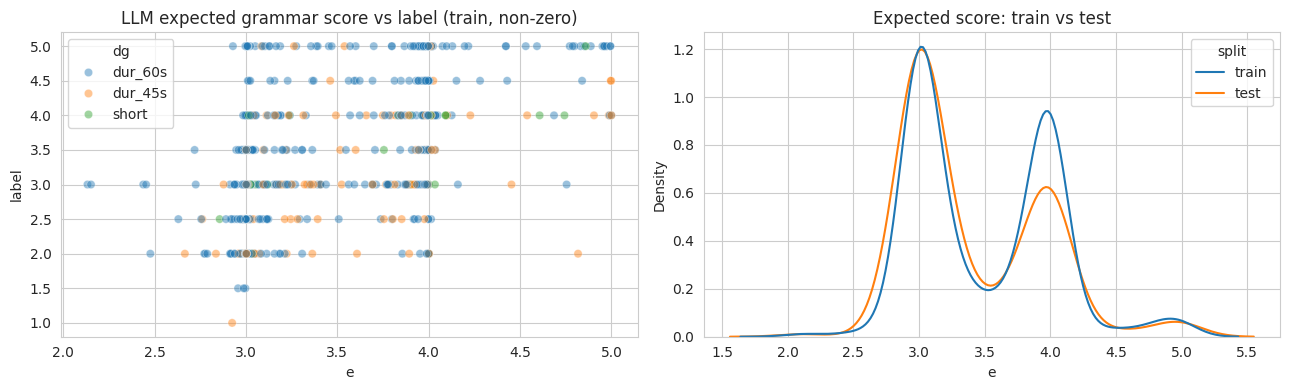

In [4]:
# L4: zero-shot score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
sns.set_style('whitegrid')

S = pd.read_csv(f'{WORK}/llm_scores.csv')
S['split'] = S.uid.str.split('/').str[0]
S['label'] = [lab[u.split('/')[1]] if u.startswith('train/') else np.nan for u in S.uid]
S['duration'] = S.uid.map(dur)
S['dg'] = np.where(S.duration < 40, 'short', np.where(S.duration < 52, 'dur_45s', 'dur_60s'))
trn, tst = S[(S.split == 'train') & (S.label > 0)], S[S.split == 'test']

print('Spearman(expected score, label), train non-zero:')
print('  all', round(spearmanr(trn.e, trn.label)[0], 3), '| n =', len(trn))
for g in ['dur_45s', 'dur_60s']:
    d = trn[trn.dg == g]
    print(f'  {g}: {spearmanr(d.e, d.label)[0]:+.3f} | n = {len(d)}')
print('\nexpected score, train vs test, by group:')
for g in ['dur_45s', 'dur_60s']:
    a, b = trn[trn.dg == g].e, tst[tst.dg == g].e
    print(f'  {g}: train mean {a.mean():.3f} | test mean {b.mean():.3f} | KS p {ks_2samp(a, b).pvalue:.4f}')
print('\nreference: Whisper-confidence feature wp_mean had Spearman +0.49 (45s) and +0.68 (60s)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=trn, x='e', y='label', hue='dg', alpha=0.45, ax=ax[0])
ax[0].set_title('LLM expected grammar score vs label (train, non-zero)')
sns.kdeplot(data=S[S.dg.isin(['dur_45s', 'dur_60s'])], x='e', hue='split', common_norm=False, ax=ax[1])
ax[1].set_title('Expected score: train vs test')
plt.tight_layout(); plt.show()